# Generating handwriting - Portfolio assignment 2 (EMNIST letters)

Dataset: `dataset/x_letters.npy` and `dataset/y_letters.npy`.

Goal: train a conditional GAN (cGAN) so the generator produces handwritten lowercase a–z conditioned on the letter class.

Implemented:
- Conditional DCGAN-style networks (Lecture 5: conv / transposed-conv, batch norm, ReLU / LeakyReLU)
- Class conditioning via `nn.Embedding` on integer labels 0 = a … 25 = z 
- `plot_string()` to render an entire word as generated letters
- Figures: training losses, fake samples per letter, latent interpolation


## Required outputs (assignment)

- Notebook with all cells run and visible output
- Short comments on approach, experiments, and findings
- cGAN implementation
- Result of **`plot_string("machine")`** (or another string)
- At least two interesting figures (training progress, interpolations, etc.)


In [1]:
%matplotlib inline

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cpu


X shape: (88799, 28, 28)
y shape: (88799,)
classes (0=a ... 25=z): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
X min/max: 0.0 1.0


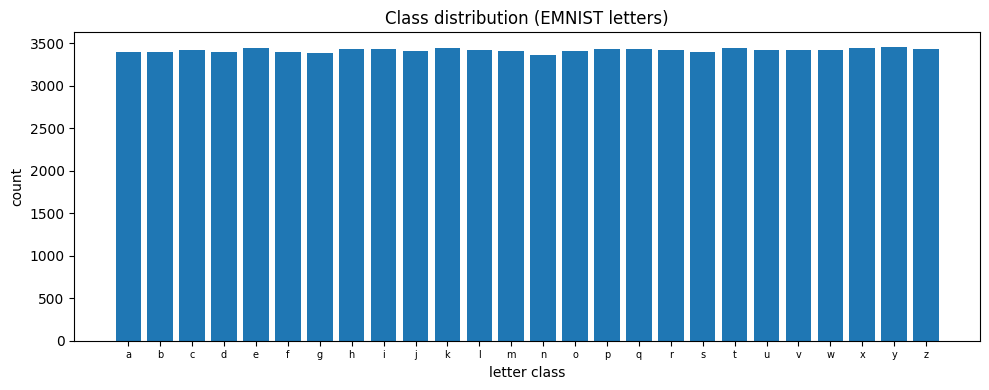

In [2]:
DATA_DIR = "dataset"
X_PATH = os.path.join(DATA_DIR, "x_letters.npy")
Y_PATH = os.path.join(DATA_DIR, "y_letters.npy")

if not os.path.exists(X_PATH) or not os.path.exists(Y_PATH):
    raise FileNotFoundError("x_letters.npy and/or y_letters.npy not found under ./dataset/.")

X_raw = np.load(X_PATH).astype(np.float32)  # (N, 28, 28)
y = np.load(Y_PATH).astype(np.int64)  # (N,) values 0..25

print("X shape:", X_raw.shape)
print("y shape:", y.shape)
print("classes (0=a ... 25=z):", np.unique(y).tolist())
print("X min/max:", float(X_raw.min()), float(X_raw.max()))

# Class distribution (same idea as Assignment 1 bar chart)
counts = np.bincount(y, minlength=26)
plt.figure(figsize=(10, 4))
plt.bar(np.arange(26), counts)
plt.xticks(np.arange(26), [chr(ord("a") + i) for i in range(26)], fontsize=7)
plt.xlabel("letter class")
plt.ylabel("count")
plt.title("Class distribution (EMNIST letters)")
plt.tight_layout()
plt.show()


## Model — conditional DCGAN

- Generator: noise `z` + embedding(label) → linear → $7\times7\times128$ → two `ConvTranspose2d` steps → $28\times28$ → `tanh`.
- Discriminator: embedding maps the label to a $28\times28$ plane, concatenated with the image as a second input channel, then strided convolutions to a real/fake logit.
- Real pixels are scaled from [0, 1] to [-1, 1] to match `tanh`.


In [3]:
class LetterDataset(Dataset):
    # Images (N,28,28); labels are integers 0..25 (a..z).

    def __init__(self, images: np.ndarray, labels: np.ndarray):
        self.images = torch.from_numpy(images).float().unsqueeze(1)
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


NUM_CLASSES = 26
NZ = 100
NDF = 64
LABEL_EMBED = 32

dataset = LetterDataset(X_raw, y)
BATCH_SIZE = 128
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)


In [4]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, LABEL_EMBED)
        self.fc = nn.Linear(NZ + LABEL_EMBED, 128 * 7 * 7)
        self.bn0 = nn.BatchNorm1d(128 * 7 * 7)
        self.net = nn.Sequential(
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=True),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        le = self.label_emb(labels)
        x = torch.cat([z, le], dim=1)
        x = self.fc(x)
        x = self.bn0(x)
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, 28 * 28)
        self.main = nn.Sequential(
            nn.Conv2d(2, NDF, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(NDF, NDF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(NDF * 2, NDF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(NDF * 4 * 3 * 3, 1),
            nn.Sigmoid(),
        )

    def forward(self, img, labels):
        le = self.label_emb(labels).view(-1, 1, 28, 28)
        x = torch.cat([img, le], dim=1)
        return self.main(x)


def weights_init(m):
    name = m.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)
G.apply(weights_init)
D.apply(weights_init)


Discriminator(
  (label_emb): Embedding(26, 784)
  (main): Sequential(
    (0): Conv2d(2, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=2304, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

## Training

We alternate D and G steps (non-saturating generator objective via `BCELoss` toward real labels for fake samples).


In [5]:
lr = 2e-4
beta1 = 0.5
criterion = nn.BCELoss()

optD = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))
optG = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))

real_label = 1.0
fake_label = 0.0


def denorm_for_plot(t):
    # tanh [-1,1] -> [0,1] for matplotlib
    return (t.clamp(-1, 1) + 1) * 0.5


In [6]:
NUM_EPOCHS = 12
loss_G_hist = []
loss_D_hist = []

fixed_noise = torch.randn(26, NZ, device=DEVICE)
fixed_labels = torch.arange(0, NUM_CLASSES, device=DEVICE)

for epoch in range(1, NUM_EPOCHS + 1):
    g_run = d_run = 0.0
    n_batches = 0
    for real, lab in loader:
        real = real.to(DEVICE)
        lab = lab.to(DEVICE)
        real = real * 2.0 - 1.0
        bsz = real.size(0)

        D.zero_grad()
        out_real = D(real, lab)
        loss_real = criterion(out_real, torch.full_like(out_real, real_label))
        z = torch.randn(bsz, NZ, device=DEVICE)
        fake = G(z, lab).detach()
        out_fake = D(fake, lab)
        loss_fake = criterion(out_fake, torch.full_like(out_fake, fake_label))
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optD.step()

        G.zero_grad()
        z = torch.randn(bsz, NZ, device=DEVICE)
        gen = G(z, lab)
        out = D(gen, lab)
        loss_G = criterion(out, torch.full_like(out, real_label))
        loss_G.backward()
        optG.step()

        g_run += loss_G.item()
        d_run += loss_D.item()
        n_batches += 1

    loss_G_hist.append(g_run / n_batches)
    loss_D_hist.append(d_run / n_batches)
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  loss_G={loss_G_hist[-1]:.4f}  loss_D={loss_D_hist[-1]:.4f}")

print("Training finished.")


Epoch 01/12  loss_G=1.9274  loss_D=0.6688
Epoch 02/12  loss_G=2.3615  loss_D=0.4637
Epoch 03/12  loss_G=2.2947  loss_D=0.5034
Epoch 04/12  loss_G=2.7006  loss_D=0.3848
Epoch 05/12  loss_G=2.9008  loss_D=0.3430
Epoch 06/12  loss_G=3.2570  loss_D=0.2577
Epoch 07/12  loss_G=3.6481  loss_D=0.2039
Epoch 08/12  loss_G=3.7171  loss_D=0.1995
Epoch 09/12  loss_G=4.0208  loss_D=0.1478
Epoch 10/12  loss_G=4.2132  loss_D=0.1519
Epoch 11/12  loss_G=4.2565  loss_D=0.1603
Epoch 12/12  loss_G=4.4478  loss_D=0.1442
Training finished.


## Figure 1 — Training losses

GAN losses are noisy; we can use this mainly to spot collapse or divergence.


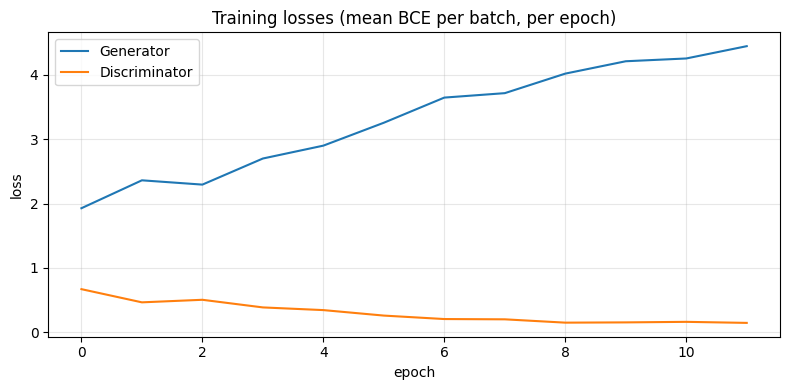

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(loss_G_hist, label="Generator")
ax.plot(loss_D_hist, label="Discriminator")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Training losses (mean BCE per batch, per epoch)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Figure 2 — One fake sample per letter (fixed noise across classes)

Each column uses the same latent draw index; labels differ so you can compare conditioning.


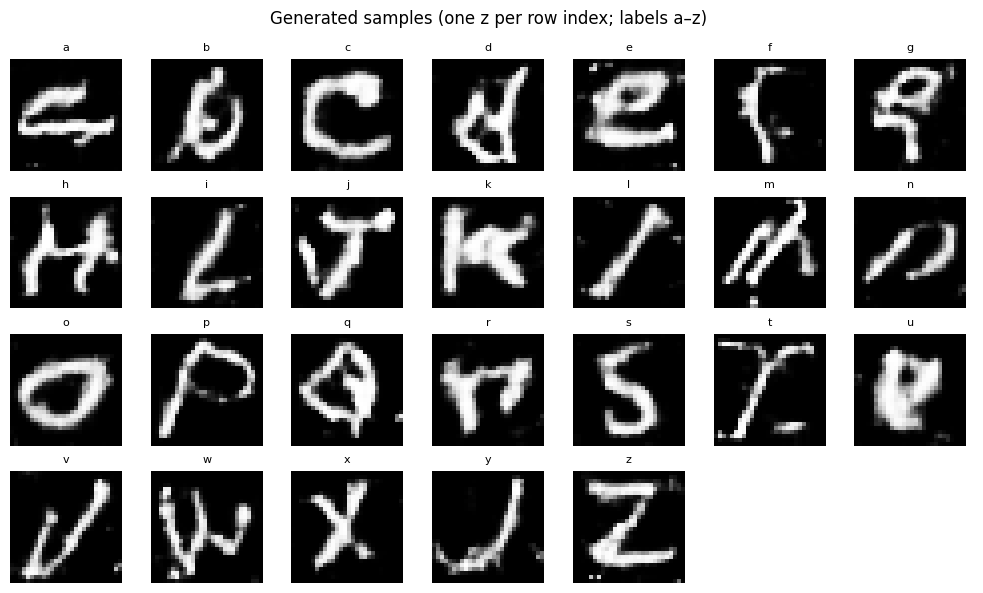

In [8]:
with torch.no_grad():
    fakes = G(fixed_noise, fixed_labels)
grid = denorm_for_plot(fakes).cpu().numpy()

fig, axes = plt.subplots(4, 7, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    if i < NUM_CLASSES:
        ax.imshow(grid[i, 0], cmap="gray", vmin=0, vmax=1)
        ax.set_title(chr(ord("a") + i), fontsize=8)
    ax.axis("off")
plt.suptitle("Generated samples (one z per row index; labels a–z)")
plt.tight_layout()
plt.show()


## Figure 3 — Latent interpolation (letter **m**)

Interpolate between two noise vectors while keeping the same label to show within-class variation.


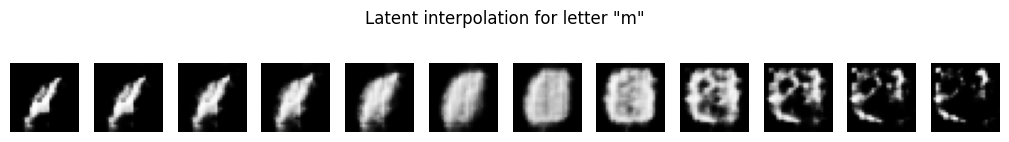

In [9]:
LETTER_M = ord("m") - ord("a")
z0 = torch.randn(1, NZ, device=DEVICE)
z1 = torch.randn(1, NZ, device=DEVICE)
steps = 12
alphas = torch.linspace(0, 1, steps, device=DEVICE).view(-1, 1)
zs = (1 - alphas) * z0 + alphas * z1
labels = torch.full((steps,), LETTER_M, dtype=torch.long, device=DEVICE)

with torch.no_grad():
    seq = G(zs, labels)

fig, axes = plt.subplots(1, steps, figsize=(steps * 0.85, 1.5))
for i in range(steps):
    axes[i].imshow(denorm_for_plot(seq[i : i + 1])[0, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[i].axis("off")
plt.suptitle("Latent interpolation for letter \"m\"")
plt.tight_layout()
plt.show()


## `plot_string`

Maps each a–z character to its class index (`ord(c) - ord('a')`), samples fresh noise per glyph, and concatenates images horizontally (small gap between letters).


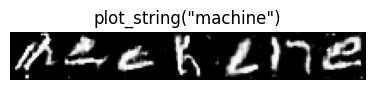

In [10]:
def plot_string(s: str, g: nn.Module, nz: int = NZ, device: torch.device = DEVICE, pad: int = 2):
    g.eval()
    s = s.lower()
    tiles = []
    for ch in s:
        if ch == " ":
            if tiles:
                tiles.append(np.zeros((28, pad), dtype=np.float32))
            continue
        if not ("a" <= ch <= "z"):
            continue
        lab = ord(ch) - ord("a")
        z = torch.randn(1, nz, device=device)
        lab_t = torch.tensor([lab], dtype=torch.long, device=device)
        with torch.no_grad():
            out = g(z, lab_t)
        img = denorm_for_plot(out)[0, 0].cpu().numpy()
        tiles.append(img)
        tiles.append(np.zeros((28, pad), dtype=np.float32))
    if not tiles:
        raise ValueError("No letters to plot — use a-z.")
    row = np.concatenate(tiles[:-1], axis=1)
    return row


row = plot_string("machine", G)
plt.figure(figsize=(len("machine") * 0.55, 1.4))
plt.imshow(row, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title('plot_string("machine")')
plt.tight_layout()
plt.show()


## Findings

- Conditioning (Lecture 5 cGAN) is necessary so the generator does not mix letters randomly.
- Training can be **unstable**; longer runs or a GPU usually improve stroke clarity.
- **No label encoding:** `y` is used as integer class ids **0–25**; only `nn.Embedding` maps them to vectors inside the model (no sklearn encoders or one-hot preprocessing).
